In [10]:
secom_final = pd.concat([X_var_df.reset_index(drop=True),
                          y_binary.reset_index(drop=True)], axis=1)
secom_final.to_csv('../data/processed/secom_clean.csv', index=False)
print(f"Saved SECOM clean: {secom_final.shape}")

Saved SECOM clean: (1567, 298)


In [9]:
from sklearn.feature_selection import VarianceThreshold

selector = VarianceThreshold(threshold=0.01)
X_var = selector.fit_transform(X_imputed)
kept_cols = X_imputed.columns[selector.get_support()]

X_var_df = pd.DataFrame(X_var, columns=kept_cols)
print(f"Columns after variance filter: {X_var_df.shape[1]}")

Columns after variance filter: 297


In [8]:
# SECOM uses -1=fail, 1=pass. Convert to 0=pass, 1=fail for consistency with AI4I
y_binary = (y == -1).astype(int).rename("failure")

print("Failure distribution after relabeling:")
print(y_binary.value_counts())
print(f"Failure rate: {y_binary.mean()*100:.2f}%")

Failure distribution after relabeling:
failure
1    1463
0     104
Name: count, dtype: int64
Failure rate: 93.36%


In [6]:
from sklearn.impute import SimpleImputer

# Step 1: Drop columns with >50% missing
threshold = 0.5
X_filtered = X.loc[:, missing_pct <= threshold]
print(f"Columns remaining after drop: {X_filtered.shape[1]}")

# Step 2: Median impute remaining missing values
imputer = SimpleImputer(strategy='median')
X_imputed = pd.DataFrame(imputer.fit_transform(X_filtered),
                          columns=X_filtered.columns)

print(f"Missing after imputation: {X_imputed.isnull().sum().sum()}")

Columns remaining after drop: 562
Missing after imputation: 0


Columns with >50% missing: 28
Columns with >90% missing: 4
Overall missing rate: 4.5%


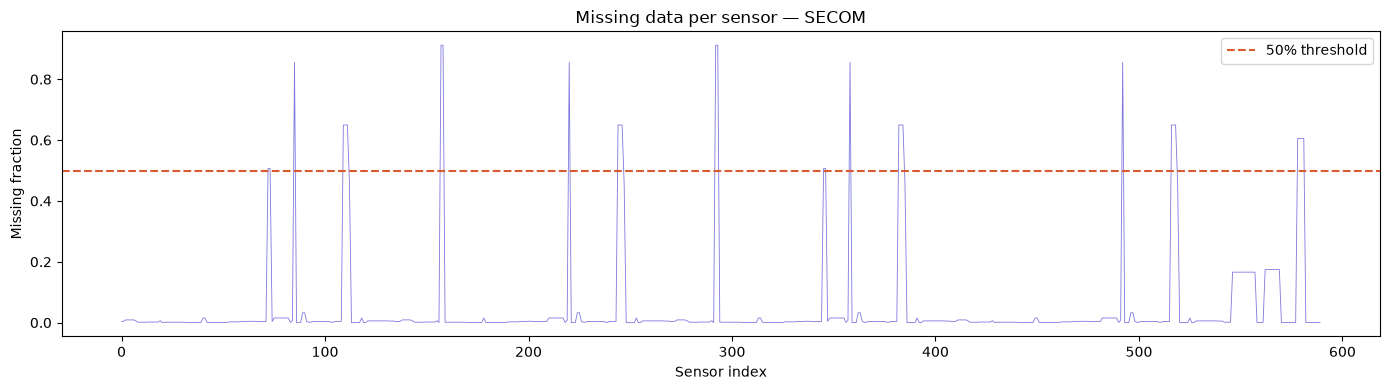

In [5]:
# How many columns have > 50% missing?
missing_pct = X.isnull().mean()
print(f"Columns with >50% missing: {(missing_pct > 0.5).sum()}")
print(f"Columns with >90% missing: {(missing_pct > 0.9).sum()}")
print(f"Overall missing rate: {X.isnull().mean().mean()*100:.1f}%")

# Visualise missing data pattern
plt.figure(figsize=(14, 4))
plt.plot(missing_pct.values, linewidth=0.6, color='#7F77DD')
plt.axhline(0.5, color='#D85A30', linestyle='--', label='50% threshold')
plt.xlabel('Sensor index')
plt.ylabel('Missing fraction')
plt.title('Missing data per sensor — SECOM')
plt.legend()
plt.tight_layout()
plt.savefig('../docs/secom_missing.png', dpi=150)
plt.show()

In [3]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=179)

print(type(dataset))
print(dataset.data)
print("features:", dataset.data.features)
print("targets:", dataset.data.targets)
print("original:", dataset.data.original)

<class 'ucimlrepo.dotdict.dotdict'>
{'ids': None, 'features': None, 'targets': None, 'original':       class            timestamp  Attribute 1  Attribute 2  Attribute 3  \
0        -1  19/07/2008 11:55:00      3030.93      2564.00    2187.7333   
1        -1  19/07/2008 12:32:00      3095.78      2465.14    2230.4222   
2         1  19/07/2008 13:17:00      2932.61      2559.94    2186.4111   
3        -1  19/07/2008 14:43:00      2988.72      2479.90    2199.0333   
4        -1  19/07/2008 15:22:00      3032.24      2502.87    2233.3667   
...     ...                  ...          ...          ...          ...   
1562     -1  16/10/2008 15:13:00      2899.41      2464.36    2179.7333   
1563     -1  16/10/2008 20:49:00      3052.31      2522.55    2198.5667   
1564     -1  17/10/2008 05:26:00      2978.81      2379.78    2206.3000   
1565     -1  17/10/2008 06:01:00      2894.92      2532.01    2177.0333   
1566     -1  17/10/2008 06:07:00      2944.92      2450.76    2195.4444   

  

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

# Fetch SECOM dataset
dataset = fetch_ucirepo(id=179)

# Full dataframe
df = dataset.data.original.copy()

# Rename class column to target for convenience
df = df.rename(columns={"class": "target"})

# Separate features and target
X = df.drop(columns=["target", "timestamp"])
y = df["target"]

print("Full dataframe shape:", df.shape)
print("Features shape:", X.shape)
print("Target shape:", y.shape)

print("\nTarget distribution:")
print(y.value_counts())

display(df.head())

Full dataframe shape: (1567, 592)
Features shape: (1567, 590)
Target shape: (1567,)

Target distribution:
target
-1    1463
 1     104
Name: count, dtype: int64


,target,timestamp,Attribute 1,Attribute 2,Attribute 3,Attribute 4,Attribute 5,Attribute 6,Attribute 7,Attribute 8,...,Attribute 581,Attribute 582,Attribute 583,Attribute 584,Attribute 585,Attribute 586,Attribute 587,Attribute 588,Attribute 589,Attribute 590
0,-1,19/07/2008 11:55:00,3030.93,2564.00,2187.7333,1411.1265,1.3602,100.0,97.6133,0.1242,...,NaN,NaN,0.5005,0.0118,0.0035,2.3630,NaN,NaN,NaN,NaN
1,-1,19/07/2008 12:32:00,3095.78,2465.14,2230.4222,1463.6606,0.8294,100.0,102.3433,0.1247,...,0.0060,208.2045,0.5019,0.0223,0.0055,4.4447,0.0096,0.0201,0.0060,208.2045
2,1,19/07/2008 13:17:00,2932.61,2559.94,2186.4111,1698.0172,1.5102,100.0,95.4878,0.1241,...,0.0148,82.8602,0.4958,0.0157,0.0039,3.1745,0.0584,0.0484,0.0148,82.8602
3,-1,19/07/2008 14:43:00,2988.72,2479.90,2199.0333,909.7926,1.3204,100.0,104.2367,0.1217,...,0.0044,73.8432,0.4990,0.0103,0.0025,2.0544,0.0202,0.0149,0.0044,73.8432
4,-1,19/07/2008 15:22:00,3032.24,2502.87,2233.3667,1326.5200,1.5334,100.0,100.3967,0.1235,...,NaN,NaN,0.4800,0.4766,0.1045,99.3032,0.0202,0.0149,0.0044,73.8432
